In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set default style
sns.set(style="whitegrid")

In [2]:
df = pd.read_csv(r"D://Guvi//Projects//mini//Amazon Delivery Time Prediction//Amazon_delivery_time_prediction//data//raw//amazon_delivery.csv")
df.head()

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys


In [3]:
print("Dataset Shape (Rows, Columns):")
print(df.shape)
print("-" * 50)

print("Dataset Info:")
print(df.info())
print("-" * 50)

print("Statistical Summary:")
print(df.describe())
print("-" * 50)

Dataset Shape (Rows, Columns):
(43739, 16)
--------------------------------------------------
Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43739 entries, 0 to 43738
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         43739 non-null  object 
 1   Agent_Age        43739 non-null  int64  
 2   Agent_Rating     43685 non-null  float64
 3   Store_Latitude   43739 non-null  float64
 4   Store_Longitude  43739 non-null  float64
 5   Drop_Latitude    43739 non-null  float64
 6   Drop_Longitude   43739 non-null  float64
 7   Order_Date       43739 non-null  object 
 8   Order_Time       43739 non-null  object 
 9   Pickup_Time      43739 non-null  object 
 10  Weather          43648 non-null  object 
 11  Traffic          43739 non-null  object 
 12  Vehicle          43739 non-null  object 
 13  Area             43739 non-null  object 
 14  Delivery_Time    43739 non-null  int64  
 

# Univariate Analysis

In [4]:
df_model = df.copy()

##### Create Distance using Haversine

In [5]:
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

df_model['Distance_km'] = haversine(
    df_model['Store_Latitude'],
    df_model['Store_Longitude'],
    df_model['Drop_Latitude'],
    df_model['Drop_Longitude']
)

In [6]:
df_model = df_model.drop(
    ['Store_Latitude', 'Store_Longitude', 'Drop_Latitude', 'Drop_Longitude'],
    axis=1
)
df_model.head()

,Order_ID,Agent_Age,Agent_Rating,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category,Distance_km
0,ialx566343618,37,4.9,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing,3.025149
1,akqg208421122,34,4.5,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics,20.183530
2,njpu434582536,23,4.4,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports,1.552758
3,rjto796129700,38,4.7,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics,7.790401
4,zguw716275638,32,4.6,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys,6.210138


In [7]:
# Separate Columns
num_cols = df_model.select_dtypes(include=np.number).columns
cat_cols = df_model.select_dtypes(exclude=np.number).columns

In [8]:
print("Numerical column:", num_cols)
print("Categirica column:", cat_cols)

Numerical column: Index(['Agent_Age', 'Agent_Rating', 'Delivery_Time', 'Distance_km'], dtype='object')
Categirica column: Index(['Order_ID', 'Order_Date', 'Order_Time', 'Pickup_Time', 'Weather',
       'Traffic', 'Vehicle', 'Area', 'Category'],
      dtype='object')


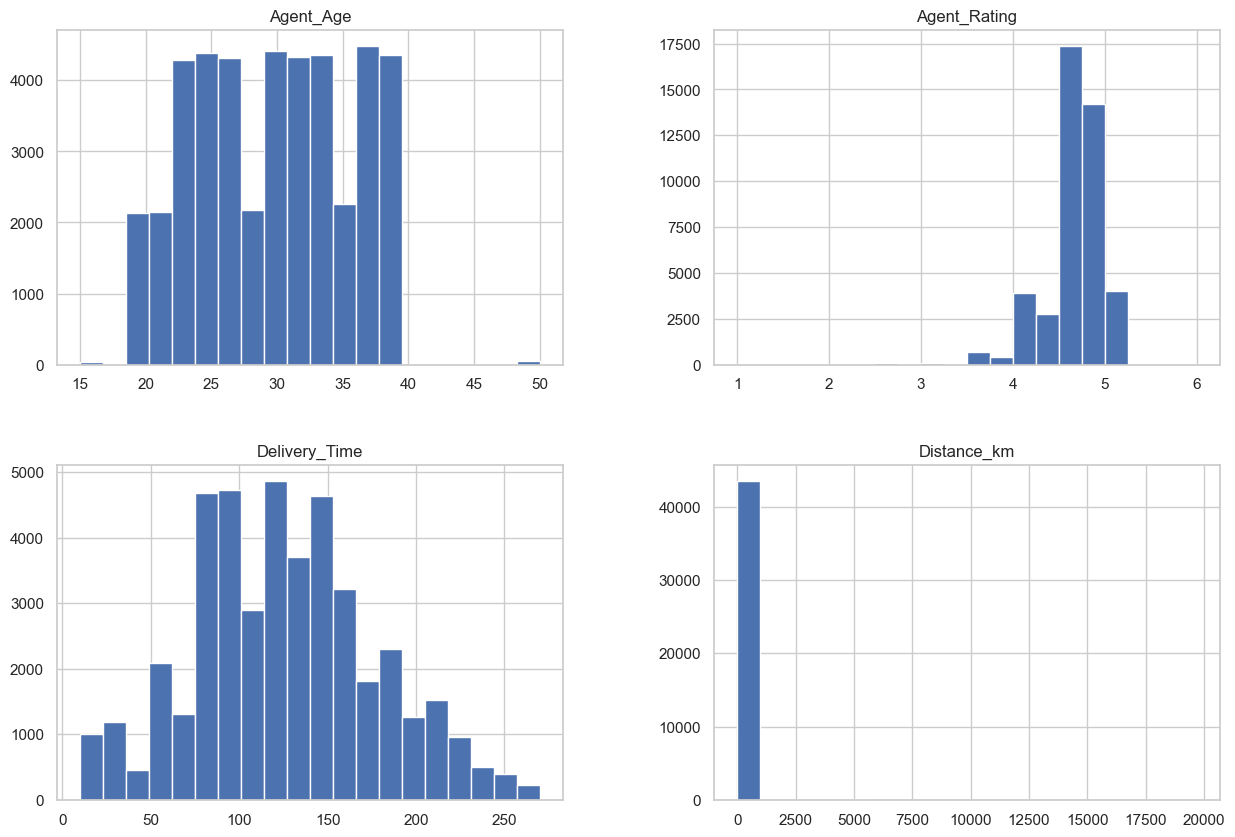

In [9]:
# Numerical Features
df_model[num_cols].hist(figsize=(15,10), bins=20)
plt.show()

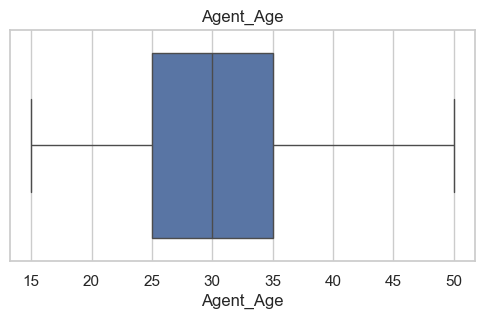

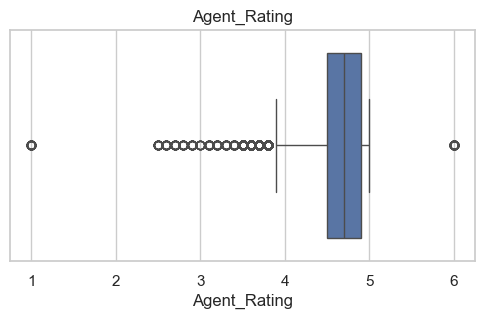

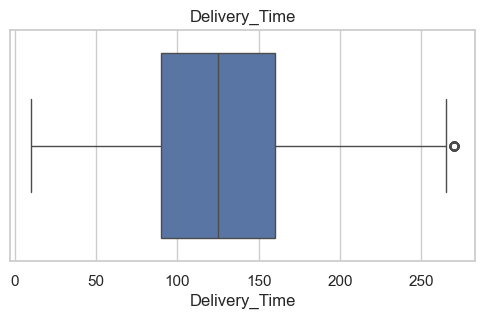

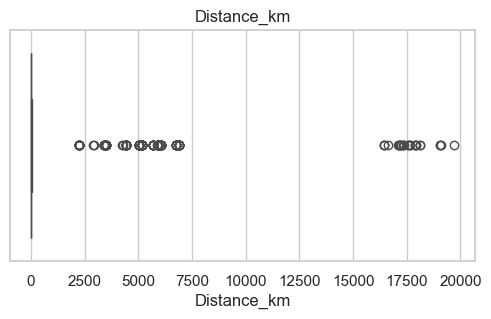

In [10]:
# Boxplot (Outliers)
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df_model[col])
    plt.title(col)
    plt.show()

In [11]:
for col in cat_cols:
    print(col, df[col].nunique())

Order_ID 43739
Order_Date 44
Order_Time 177
Pickup_Time 193
Weather 6
Traffic 5
Vehicle 4
Area 4
Category 16


In [12]:
cat_cols = [
    col for col in cat_cols
    if df_model[col].nunique() <= 20
]

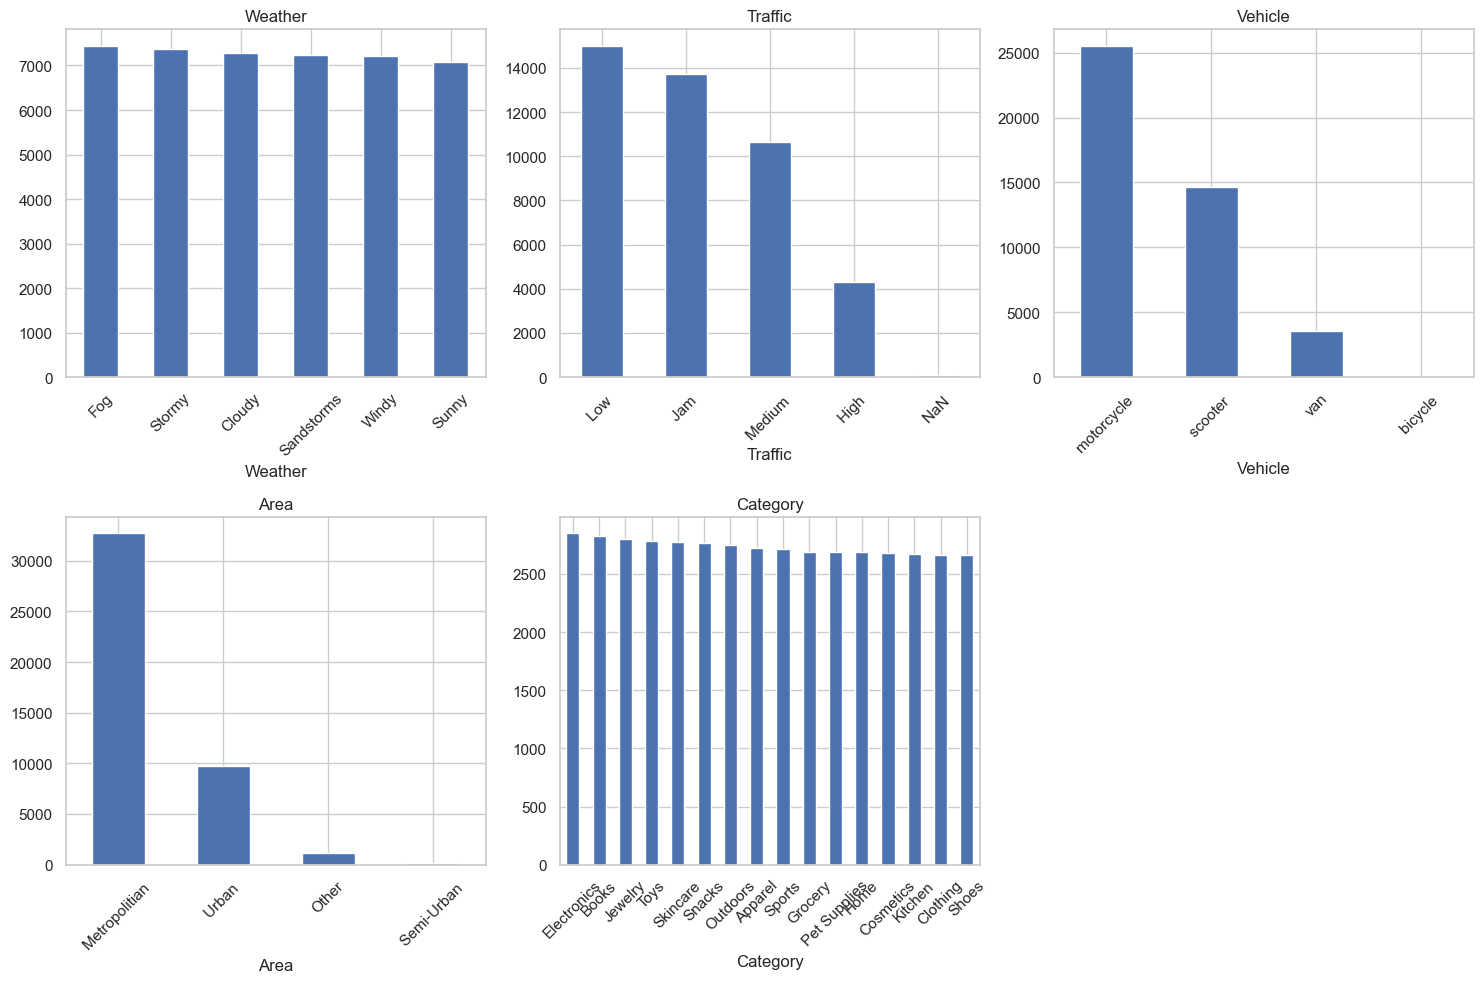

In [13]:
import matplotlib.pyplot as plt
import math

cols = len(cat_cols)
rows = math.ceil(cols / 3)

plt.figure(figsize=(15, 5 * rows))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(rows, 3, i)
    
    df_model[col].value_counts().plot(kind='bar')
    
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

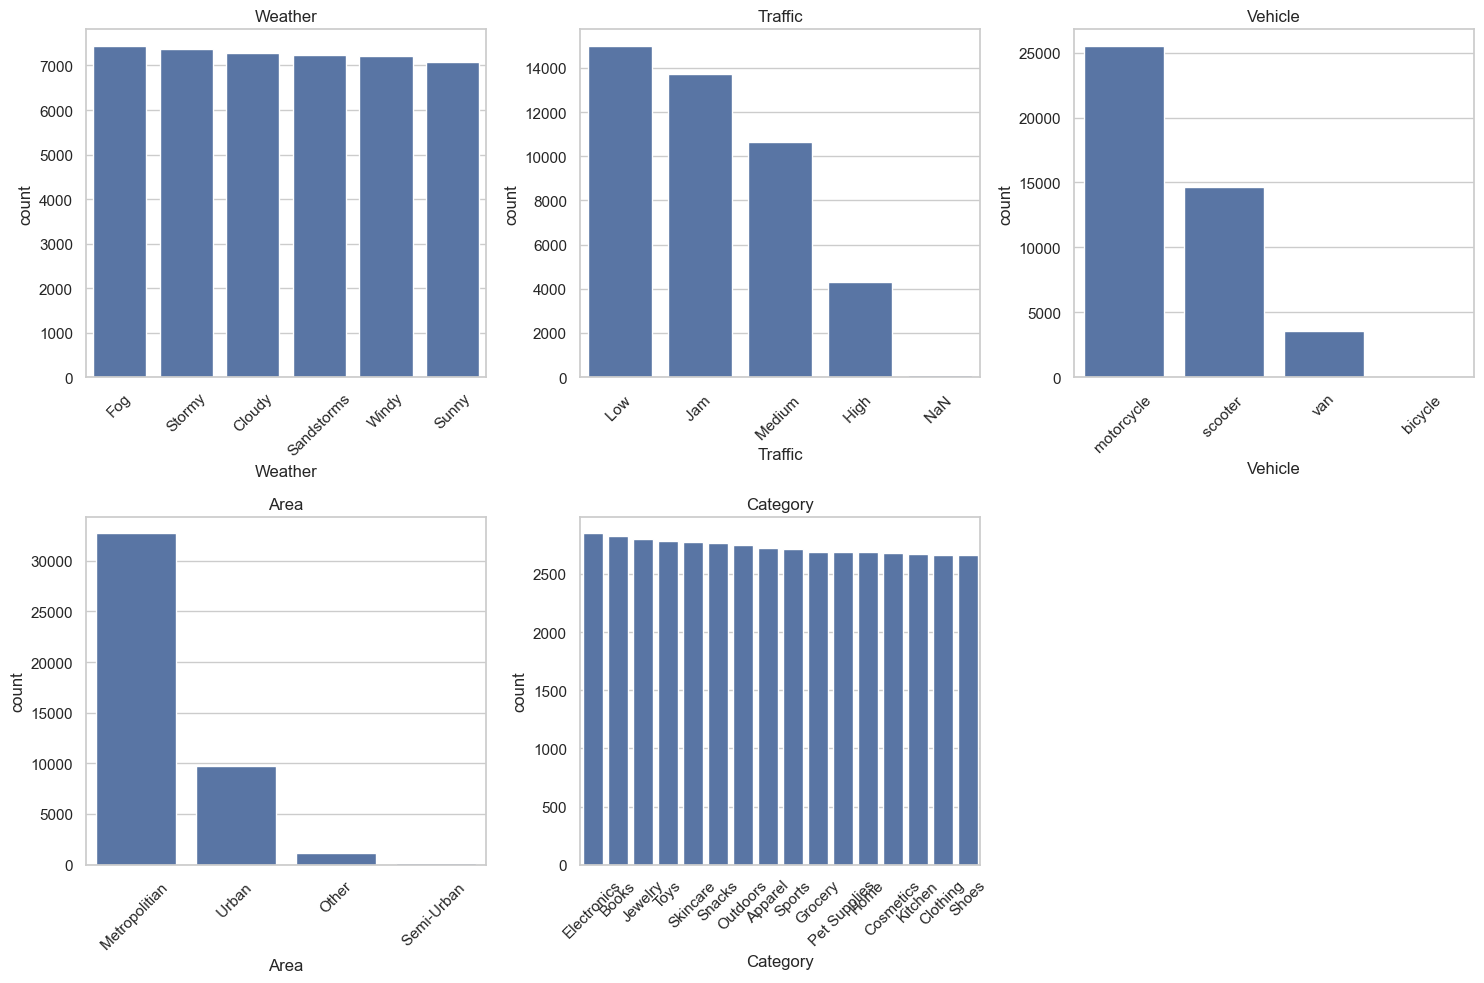

In [14]:
import seaborn as sns

cols = len(cat_cols)
rows = math.ceil(cols / 3)

plt.figure(figsize=(15, 5 * rows))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(rows, 3, i)
    
    sns.countplot(
        x=col,
        data=df_model,
        order=df_model[col].value_counts().index
    )
    
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Delivery Time Distribution

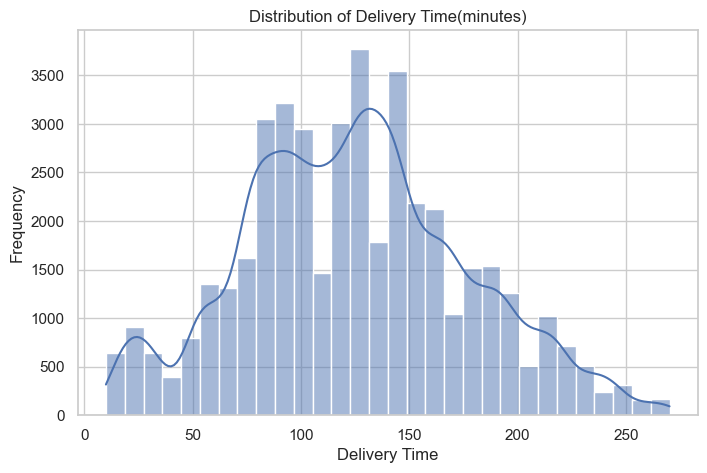

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(
    df['Delivery_Time'], 
    bins=30, 
    kde=True
)
plt.title("Distribution of Delivery Time(minutes)")
plt.xlabel("Delivery Time")
plt.ylabel("Frequency")
plt.show()

# Bivariate Analysis

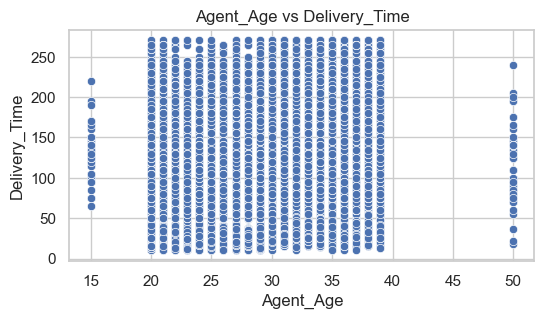

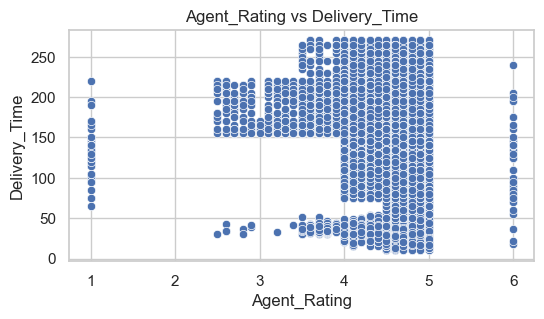

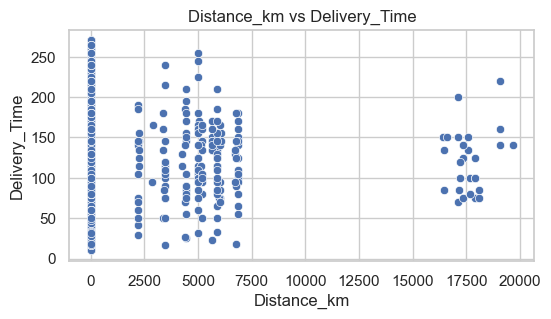

In [16]:
# Numerical vs Target
target = "Delivery_Time" 

for col in num_cols:
    if col != target:
        plt.figure(figsize=(6,3))
        sns.scatterplot(x=df_model[col], y=df_model[target])
        plt.title(f"{col} vs {target}")
        plt.show()

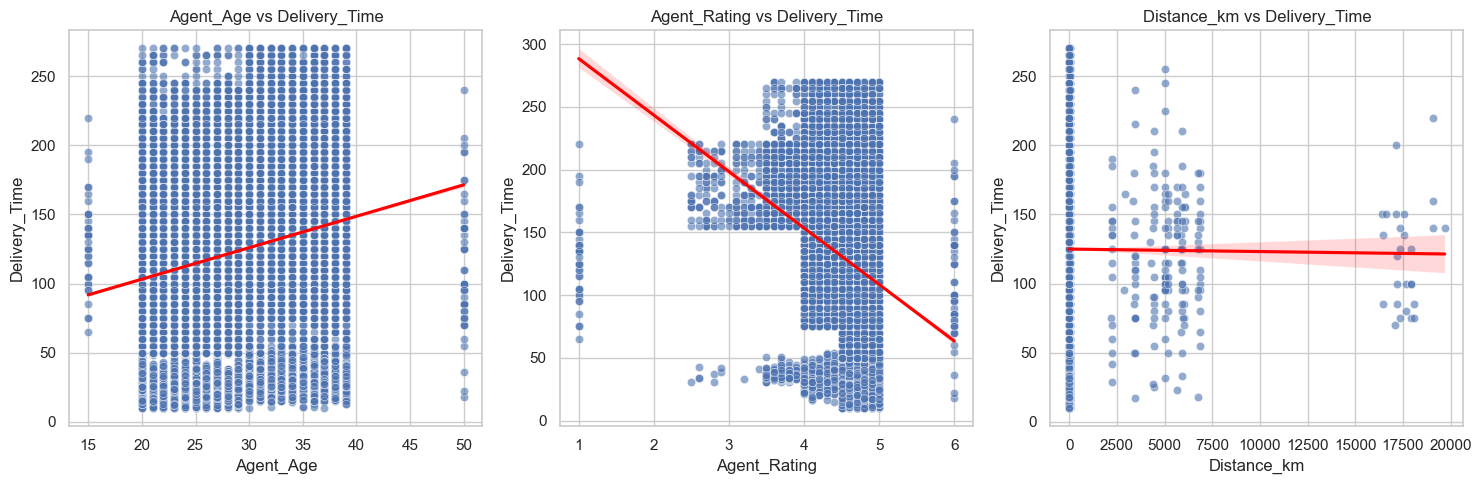

In [ ]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

target = "Delivery_Time"

num_cols_filtered = [col for col in num_cols if col != target]

cols = len(num_cols_filtered)
rows = math.ceil(cols / 3)

plt.figure(figsize=(15, 5 * rows))

for i, col in enumerate(num_cols_filtered, 1):
    plt.subplot(rows, 3, i)
    
    sns.scatterplot(
        x=df_model[col],
        y=df_model[target],
        alpha=0.6
    )
    
    sns.regplot(
        x=df_model[col],
        y=df_model[target],
        scatter=False,
        color='red'
    )
    
    plt.title(f"{col} vs {target}")

plt.tight_layout()
plt.show()

C:\Users\shubh\AppData\Local\Temp\ipykernel_13220\1727263106.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\shubh\AppData\Local\Temp\ipykernel_13220\1727263106.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\shubh\AppData\Local\Temp\ipykernel_13220\1727263106.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\shubh\AppData\Local\Temp\ipykernel_13220\1727263106.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

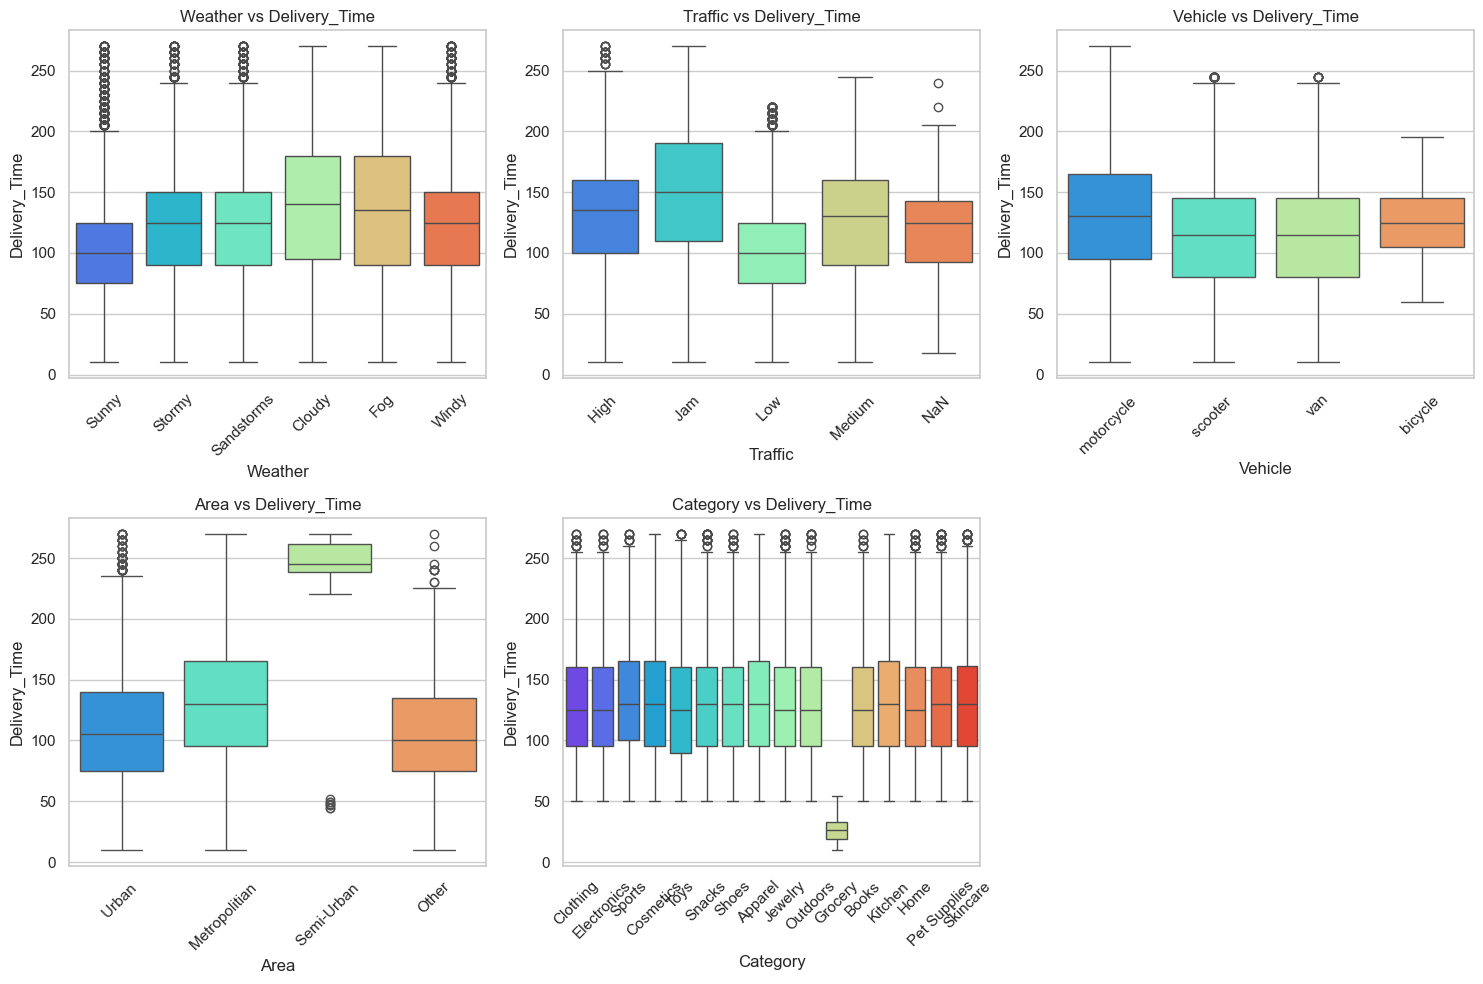

In [18]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

target = "Delivery_Time"

cat_cols_filtered = [
    col for col in cat_cols
    if df_model[col].nunique() <= 20
]

cols = len(cat_cols_filtered)
rows = math.ceil(cols / 3)

plt.figure(figsize=(15, 5 * rows))

for i, col in enumerate(cat_cols_filtered, 1):
    plt.subplot(rows, 3, i)
    
    sns.boxplot(
        x=df_model[col],
        y=df_model[target],
        palette='rainbow'
    )
    
    plt.title(f"{col} vs {target}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

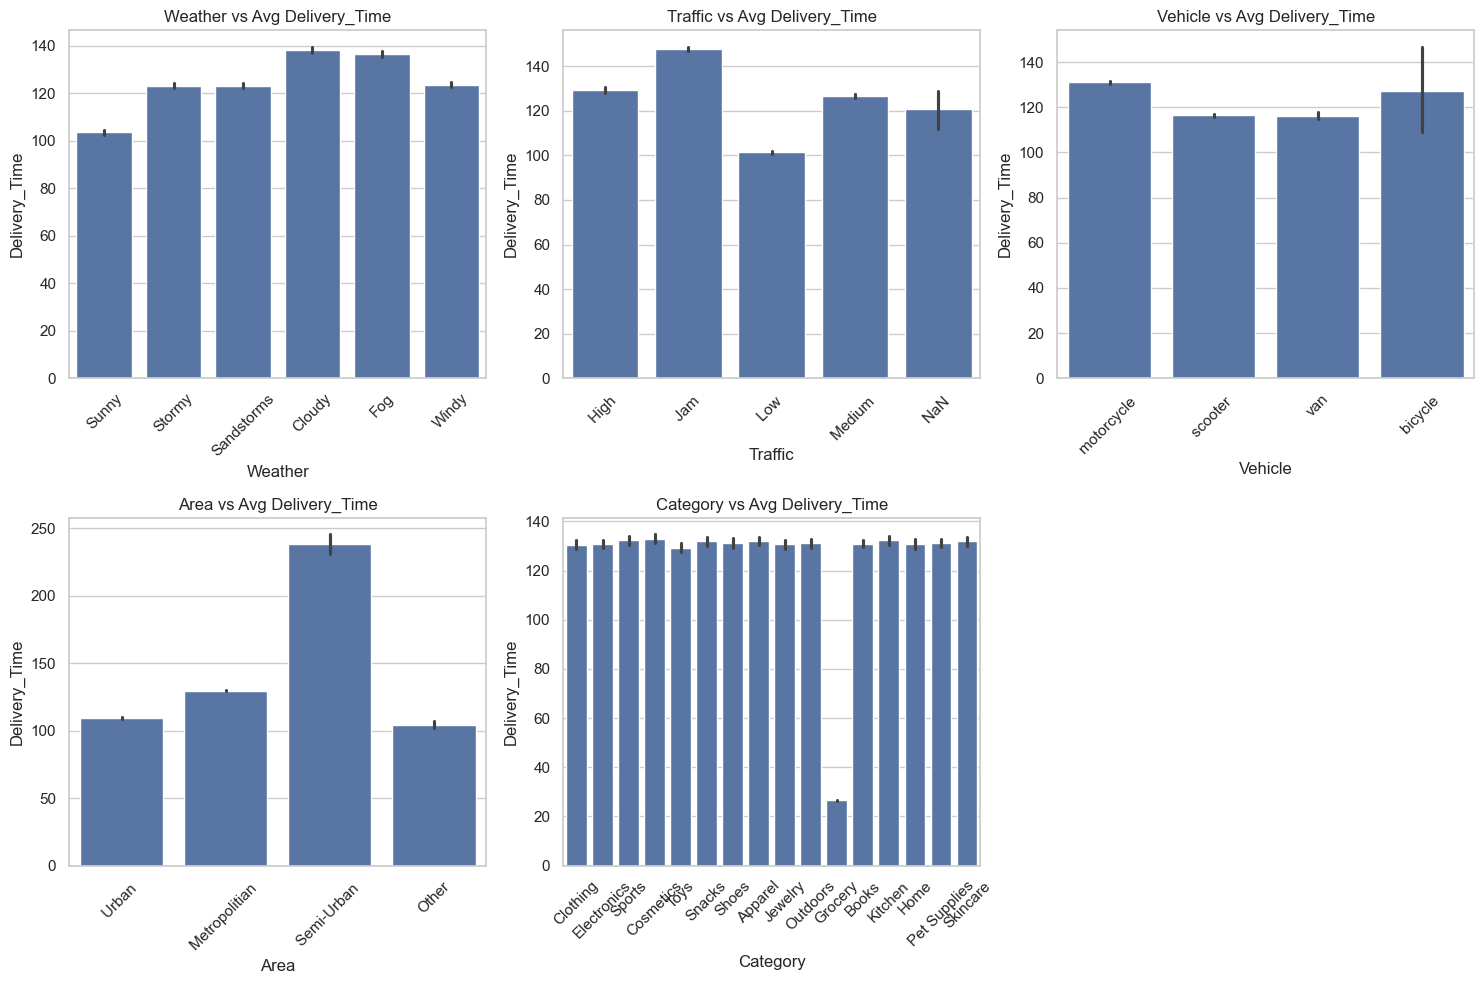

In [19]:
plt.figure(figsize=(15, 5 * rows))

for i, col in enumerate(cat_cols_filtered, 1):
    plt.subplot(rows, 3, i)
    
    sns.barplot(
        x=df_model[col],
        y=df_model[target],
        estimator='mean'
    )
    
    plt.title(f"{col} vs Avg {target}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Impact of Weather & Traffic

C:\Users\shubh\AppData\Local\Temp\ipykernel_13220\3310920299.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Figure size 800x500 with 0 Axes>

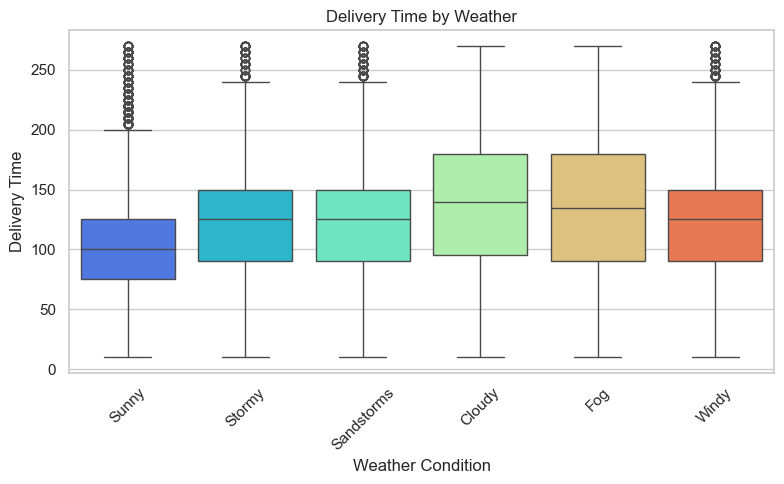

In [20]:
# Weather Impact
plt.figure(figsize=(8, 5))

plt.figure(figsize=(8,5))
sns.boxplot(
    x='Weather', 
    y='Delivery_Time', 
    data=df, 
    palette='rainbow'
)
plt.title("Delivery Time by Weather")
plt.xlabel("Weather Condition")
plt.ylabel("Delivery Time")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

C:\Users\shubh\AppData\Local\Temp\ipykernel_13220\1530843414.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


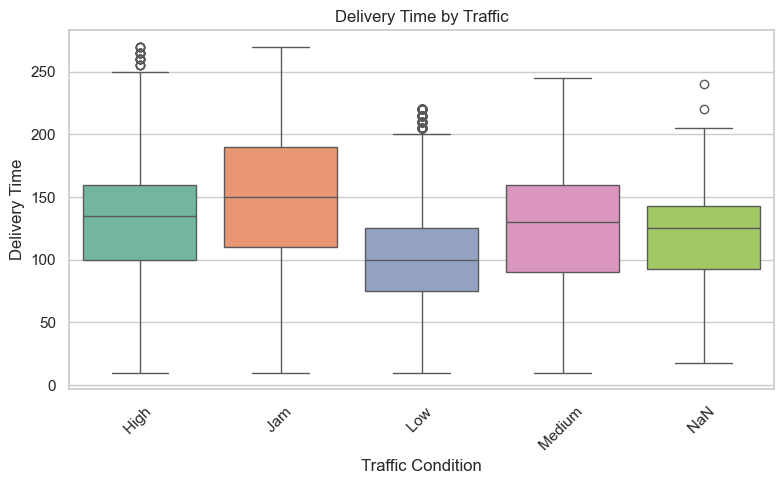

In [21]:
# Traffic Impact
plt.figure(figsize=(8, 5))

sns.boxplot(
    x='Traffic',
    y='Delivery_Time',
    data=df,
    palette='Set2'  
)

plt.title("Delivery Time by Traffic")
plt.xlabel("Traffic Condition")
plt.ylabel("Delivery Time")

plt.xticks(rotation=45)
plt.tight_layout() 

plt.show()

## Distance vs Delivery Time

In [22]:
print(df.columns)

Index(['Order_ID', 'Agent_Age', 'Agent_Rating', 'Store_Latitude',
       'Store_Longitude', 'Drop_Latitude', 'Drop_Longitude', 'Order_Date',
       'Order_Time', 'Pickup_Time', 'Weather', 'Traffic', 'Vehicle', 'Area',
       'Delivery_Time', 'Category'],
      dtype='object')


In [23]:
# Add Distance Feature
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

# Create new column
df['Distance_km'] = haversine(
    df['Store_Latitude'],
    df['Store_Longitude'],
    df['Drop_Latitude'],
    df['Drop_Longitude']
)

In [24]:
df

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category,Distance_km
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing,3.025149
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics,20.183530
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports,1.552758
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics,7.790401
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys,6.210138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43734,jlxf819993117,30,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,11:35:00,11:45:00,Windy,High,motorcycle,Metropolitian,160,Home,1.489846
43735,aevx342135787,21,4.6,0.000000,0.000000,0.070000,0.070000,2022-02-16,19:55:00,20:10:00,Windy,Jam,motorcycle,Metropolitian,180,Jewelry,11.007735
43736,xnek760674819,30,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,23:50:00,00:05:00,Cloudy,Low,scooter,Metropolitian,80,Home,4.657195
43737,cynl434665991,20,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,13:35:00,13:40:00,Cloudy,High,motorcycle,Metropolitian,130,Kitchen,6.232393


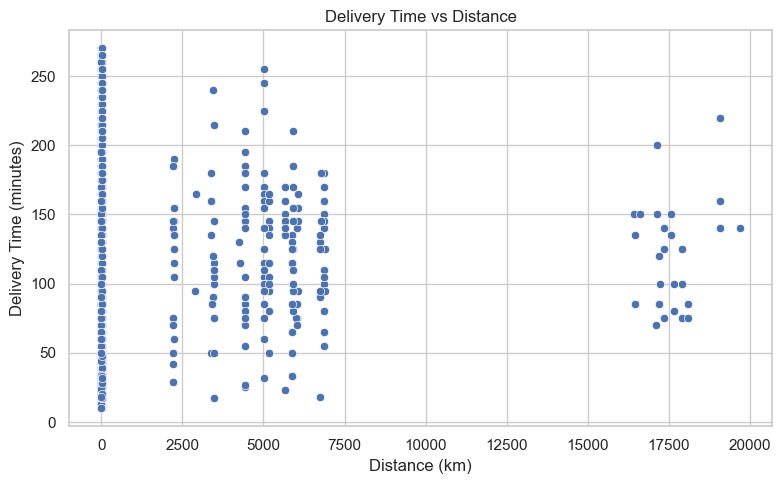

In [25]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x='Distance_km',
    y='Delivery_Time',
    data=df
)

plt.title("Delivery Time vs Distance")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (minutes)")

plt.tight_layout()
plt.show()

In [26]:
print(df[['Distance_km', 'Delivery_Time']].corr())

               Distance_km  Delivery_Time
Distance_km       1.000000      -0.001864
Delivery_Time    -0.001864       1.000000


### Agent Rating vs Delivery Time

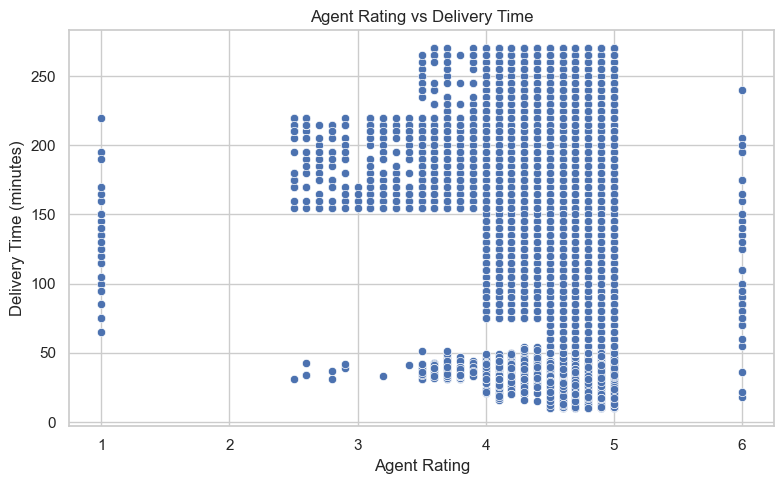

In [27]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x='Agent_Rating',
    y='Delivery_Time',
    data=df
)

plt.title("Agent Rating vs Delivery Time")
plt.xlabel("Agent Rating")
plt.ylabel("Delivery Time (minutes)")

plt.tight_layout()
plt.show()

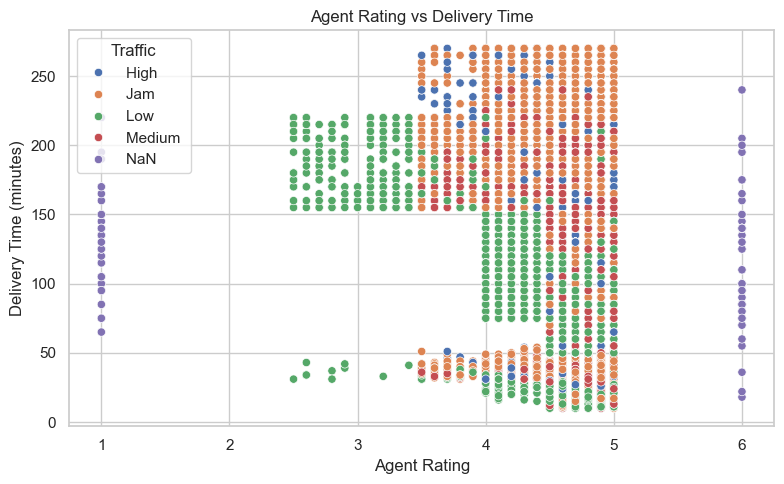

In [28]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x='Agent_Rating',
    y='Delivery_Time',
    hue='Traffic',
    data=df
)

plt.title("Agent Rating vs Delivery Time")
plt.xlabel("Agent Rating")
plt.ylabel("Delivery Time (minutes)")

plt.tight_layout()
plt.show()

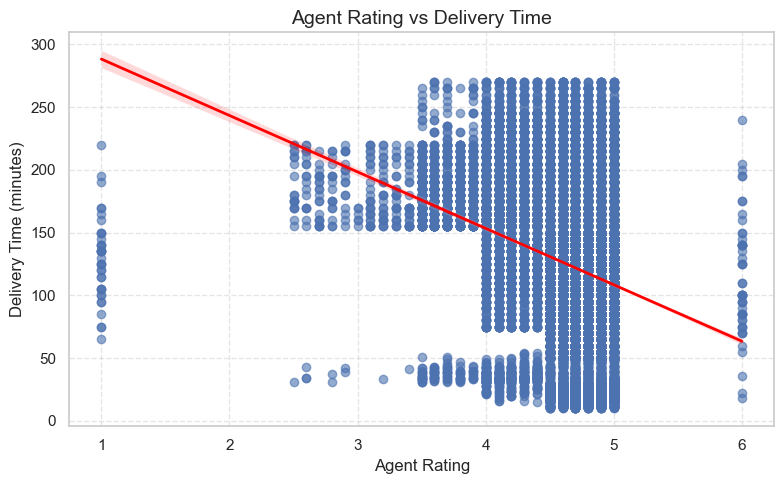

In [29]:
plt.figure(figsize=(8, 5))

sns.regplot(
    x='Agent_Rating',
    y='Delivery_Time',
    data=df,
    scatter_kws={'alpha': 0.6},   # makes points clearer
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title("Agent Rating vs Delivery Time", fontsize=14)
plt.xlabel("Agent Rating")
plt.ylabel("Delivery Time (minutes)")

plt.grid(True, linestyle='--', alpha=0.5)   # adds readability
plt.tight_layout()

plt.show()

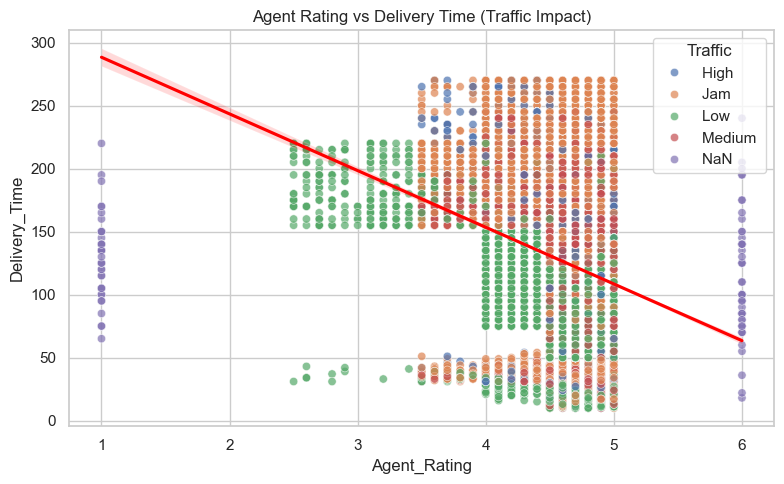

In [30]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x='Agent_Rating',
    y='Delivery_Time',
    hue='Traffic',
    data=df,
    alpha=0.7
)

sns.regplot(
    x='Agent_Rating',
    y='Delivery_Time',
    data=df,
    scatter=False,
    color='red'
)

plt.title("Agent Rating vs Delivery Time (Traffic Impact)")
plt.tight_layout()
plt.show()

## Delivery Time by Product Category

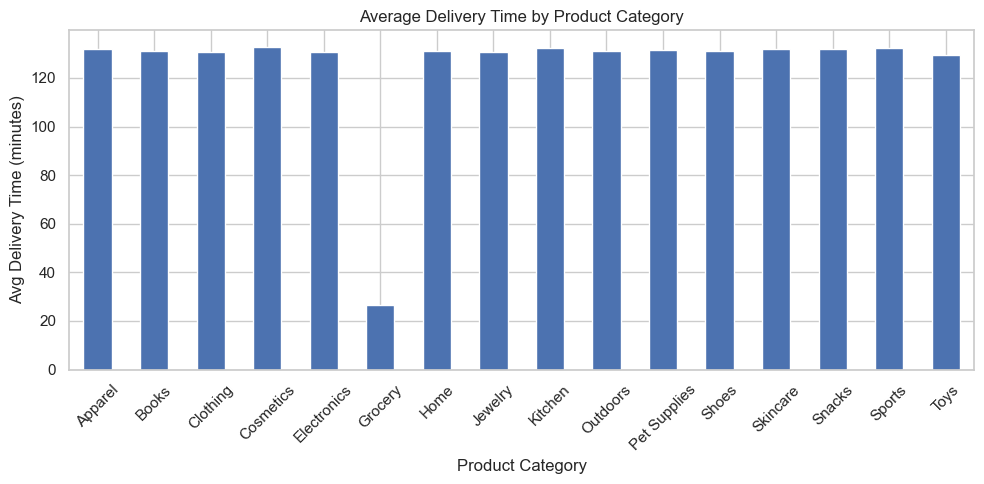

In [31]:
plt.figure(figsize=(10, 5))

df.groupby('Category')['Delivery_Time'].mean().plot(kind='bar')

plt.title("Average Delivery Time by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Avg Delivery Time (minutes)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

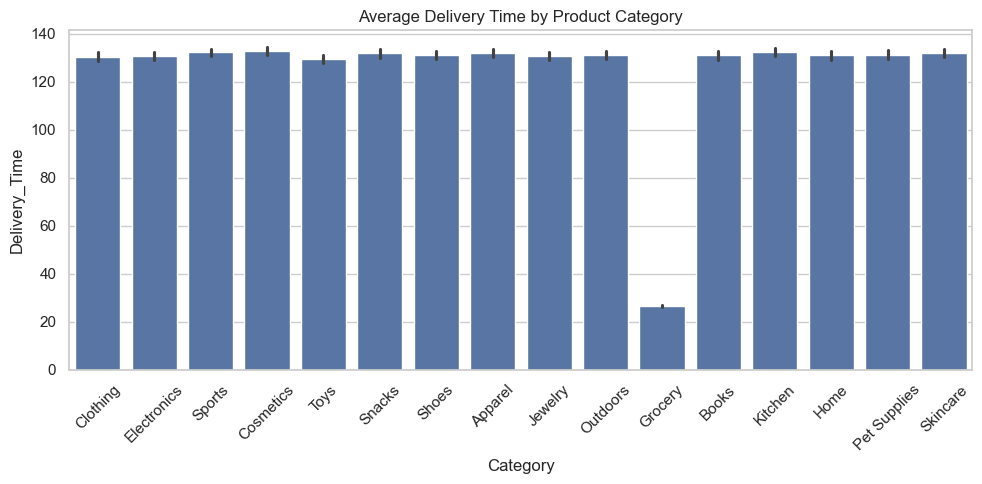

In [32]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x='Category',
    y='Delivery_Time',
    data=df,
    estimator='mean'
)

plt.title("Average Delivery Time by Product Category")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

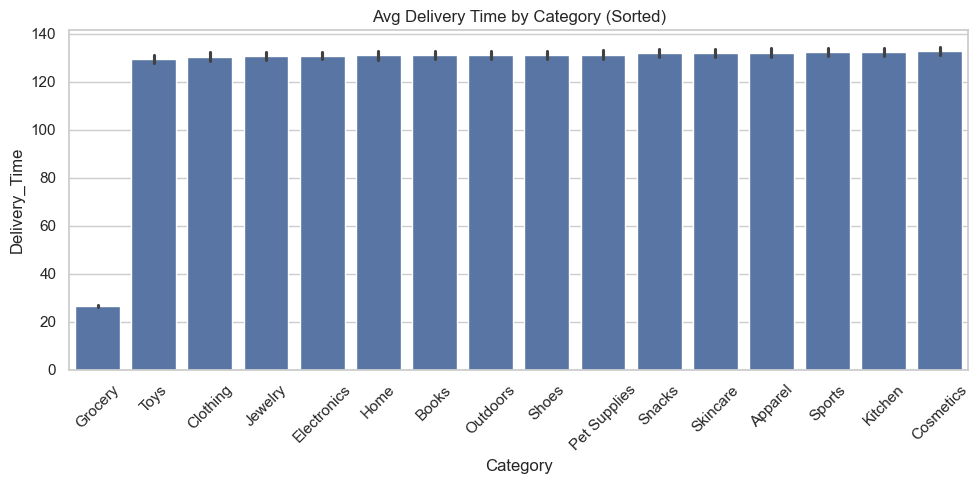

In [33]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x='Category',
    y='Delivery_Time',
    data=df,
    estimator='mean',
    order=df.groupby('Category')['Delivery_Time'].mean().sort_values().index
)

plt.title("Avg Delivery Time by Category (Sorted)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Correlation Heatmap

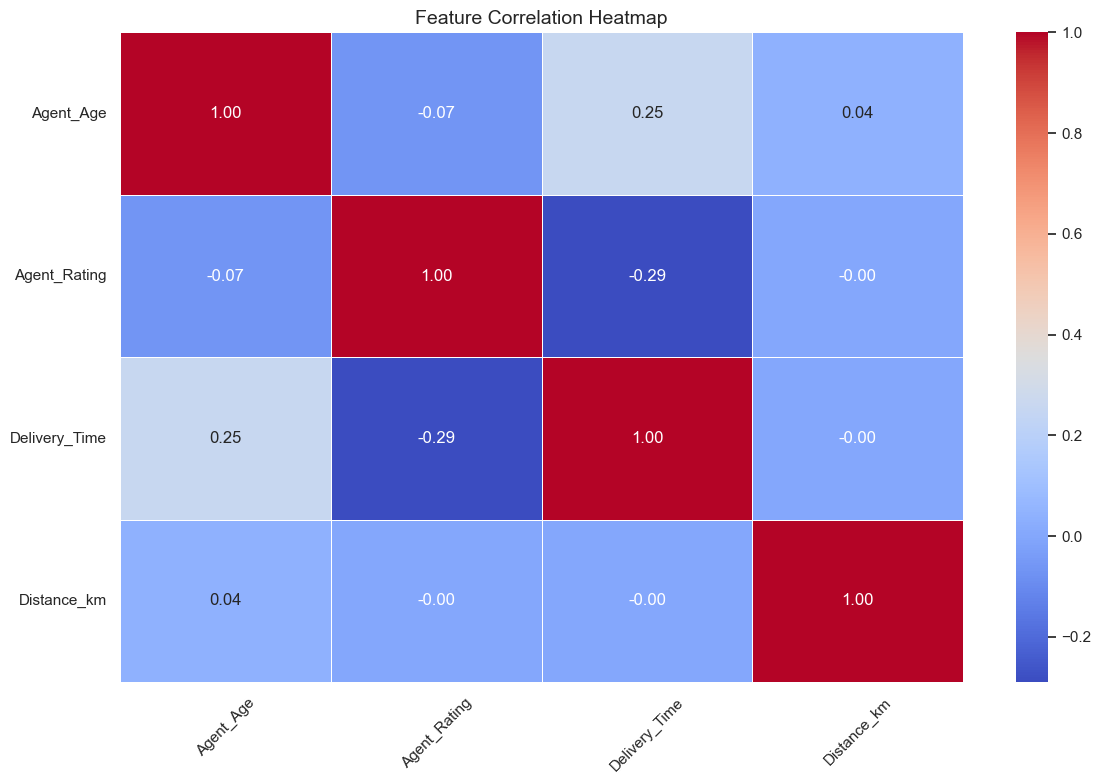

In [34]:
plt.figure(figsize=(12, 8))

corr = df_model.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",           # show 2 decimal places
    cmap='coolwarm',
    linewidths=0.5,
    cbar=True
)

plt.title("Feature Correlation Heatmap", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Delivery Time by Day of Week

In [35]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

df['Order_DayOfWeek'] = df['Order_Date'].dt.dayofweek

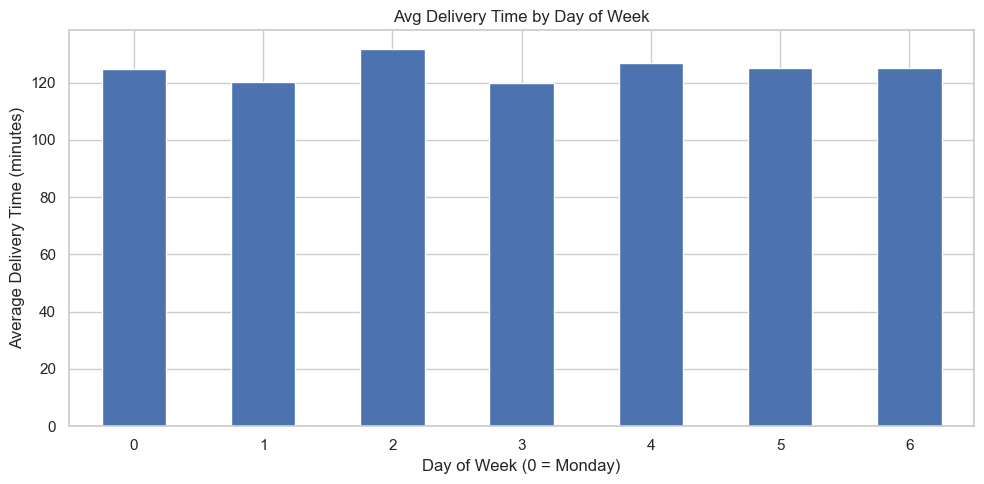

In [36]:
plt.figure(figsize=(10, 5))

df.groupby('Order_DayOfWeek')['Delivery_Time'].mean().plot(kind='bar')

plt.title("Avg Delivery Time by Day of Week")
plt.xlabel("Day of Week (0 = Monday)")
plt.ylabel("Average Delivery Time (minutes)")

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

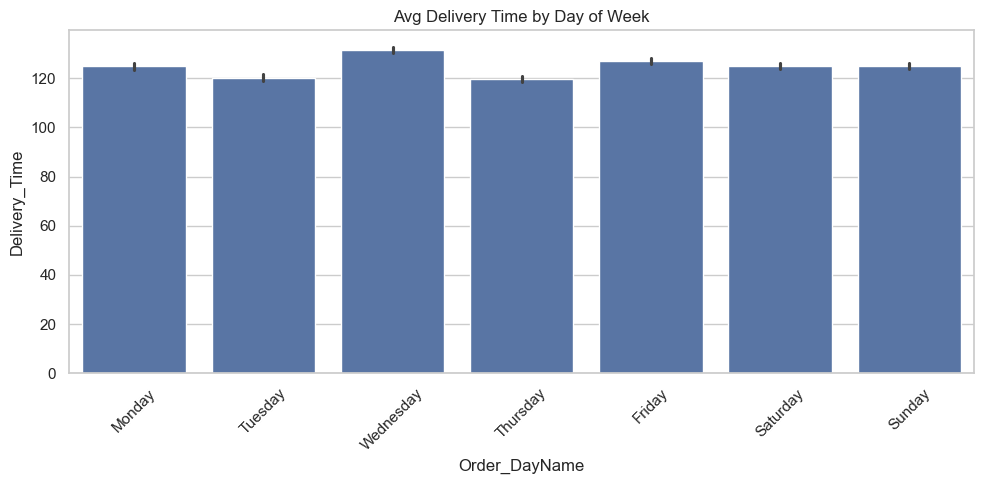

In [37]:
df['Order_DayName'] = df['Order_Date'].dt.day_name()

order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 5))

sns.barplot(
    x='Order_DayName',
    y='Delivery_Time',
    data=df,
    order=order
)

plt.title("Avg Delivery Time by Day of Week")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Pairplot

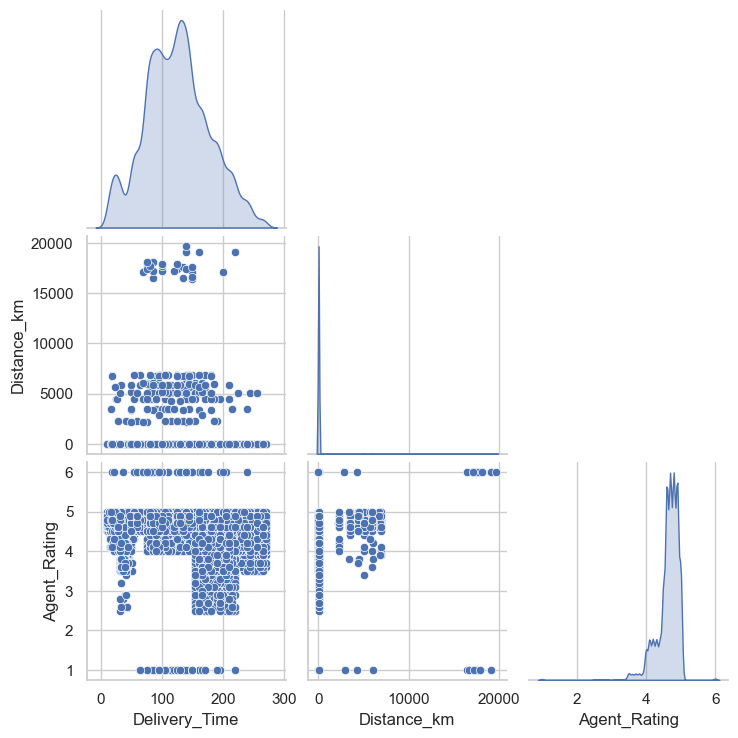

In [38]:
sns.pairplot(
    df_model[['Delivery_Time', 'Distance_km', 'Agent_Rating']],
    diag_kind='kde',     
    corner=True          
)

plt.show()

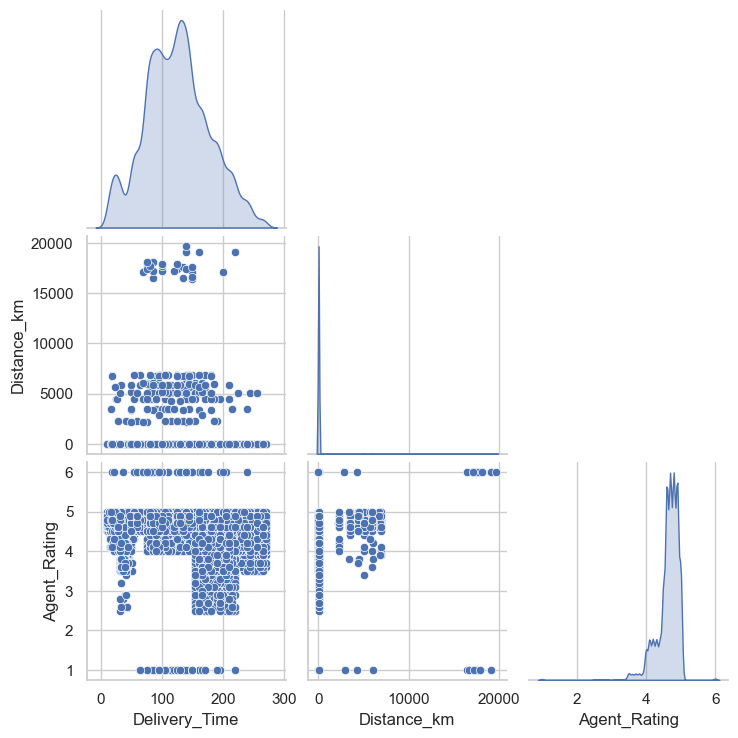

In [39]:
sns.pairplot(
    df[['Delivery_Time', 'Distance_km', 'Agent_Rating']],
    diag_kind='kde',     
    corner=True          
)

plt.show()

### Save Processed Insights

In [40]:
# # Save summary stats or visualizations if needed
# summary = df.describe()
# summary.to_csv(r"D:\Guvi\Projects\mini\Amazon Delivery Time Prediction\Amazon_delivery_time_prediction\data\processed\summary_statistics.csv")
# print("✅ Summary statistics saved.")